[pystran](https://github.com/PetrKryslUCSD/pystran) - Python package for structural analysis with trusses and beams

(C) 2025-2026, Petr Krysl, pkrysl@ucsd.edu

# Continuous beam with distributed loading

Last updated: 07/15/26

## Problem description

Continuous simply supported beam with two spans. The span on the left with
uniform distributed loading (downwards).

Displacements and internal forces are provided in the textbook.

## References

Example 5.6 from Matrix Structural Analysis: Second Edition 2nd Edition by
William McGuire, Richard H. Gallagher, Ronald D. Ziemian

## Documentation

[pystran docs](https://petrkryslucsd.github.io/pystran)


In [32]:
import scipy
from numpy import dot
from numpy.linalg import norm
import context
from pystran import model
from pystran import section
from pystran import geometry
from pystran import plots

The material is the same for all spans.


In [33]:
E = 200000 * 10**6  # Pa

The beam members in the two spans have different material properties and
cross sectional properties. We create two separate sections for the two
spans.
Span on the left (the one with the distributed loading).


In [34]:
A1 = 6000 * 10**-6  # millimeters to meters
I1 = 200 * 10**6 * 10**-12  # millimeters to meters
lss = section.beam_2d_section("left_span_section", E, A1, I1)
# Span on the right.
A2 = 4000 * 10**-6  # millimeters to meters
I2 = 50 * 10**6 * 10**-12  # millimeters to meters
rss = section.beam_2d_section("right_span_section", E, A2, I2)


Distributed loading on the left span.


In [35]:
q = 2.0e3  # kN/m

First we solve the problem with the minimum number of members. A single
member is used for the left span. Two members are used for the right span,
because there is a concentrated force at an intermediate point.


In [36]:
m = model.create(2)
freedoms = m["freedoms"]

The minimum number of joints is four (three members).


In [37]:
model.add_joint(m, "a", [0.0, 0.0])  # Roller.
model.add_joint(m, "b", [8.0, 0.0])  # Roller.
model.add_joint(m, "d", [10.0, 0.0])  # Intermediate joint with concentrated force.
model.add_joint(m, "c", [13.0, 0.0])  # Clamped end.

Supports.


In [38]:
model.add_support(m["joints"]["c"], freedoms.ALL_DOFS)
model.add_support(m["joints"]["a"], freedoms.TRANSLATION_DOFS)
model.add_support(m["joints"]["b"], freedoms.TRANSLATION_DOFS)

Beam members for the right span.


In [39]:
model.add_beam_member(m, "rs-1", ["b", "d"], rss)
model.add_beam_member(m, "rs-2", ["d", "c"], rss)

Concentrated force on the right span.


In [40]:
model.add_load(m["joints"]["d"], freedoms.U2, -20e3)

Beam member for the left span.


In [41]:
model.add_beam_member(m, "ls-1", ["a", "b"], lss)


Compute the equivalent nodal loads due to the distributed loading on the left
hand side span.


In [42]:
member = m["beam_members"]["ls-1"]
c = member["connectivity"]
i, j = m["joints"][c[0]], m["joints"][c[1]]
h = geometry.vlen(i["coordinates"], j["coordinates"])
model.add_load(i, freedoms.U2, -q * h / 2)
model.add_load(j, freedoms.U2, -q * h / 2)
model.add_load(i, freedoms.UR3, -q * h**2 / 12)
model.add_load(j, freedoms.UR3, +q * h**2 / 12)


Solve the problem, report the displacements.


In [43]:
model.number_dofs(m)
model.solve_statics(m)

In [44]:
print("Displacements at the joints (minimum number of members):")
for j in m["joints"].values():
    if "displacements" in j:
        print(f"{j['jid']}: {j['displacements']}")


Displacements at the joints (minimum number of members):
a: [ 0.          0.         -0.00056812]
b: [0.00000000e+00 0.00000000e+00 6.95652174e-05]
d: [ 0.         -0.00110191 -0.00029635]
c: [0. 0. 0.]


Plot the bending moments. Notice that the bending moment does not vanish at
the left hand side. The bending moment there is equal to the equivalent nodal
moment, q*h**2/12 = 2000 * 8**2 / 12 = 10666.66 [Nm].


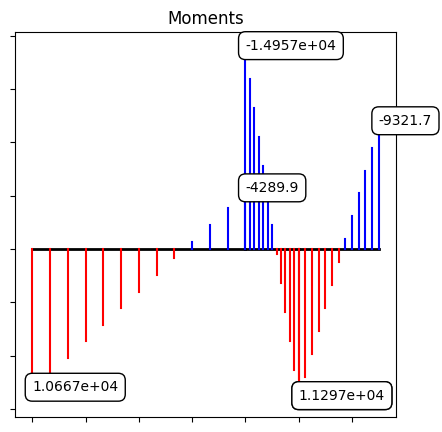

In [45]:
plots.setup(m)
plots.plot_members(m)
ax = plots.plot_bending_moments(m, scale=0.0005)
ax.set_title("Moments")
plots.show(m)

We can calculate the reactions at the supports. This is the manual approach
using the partitioning of the stiffness matrix and the displacement
vector.


In [46]:
nt = m["ntotaldof"]
nf = m["nfreedof"]
Kdf = m["K"][nf:nt, 0:nf]
Kdd = m["K"][nf:nt, nf:nt]
Uf = m["U"][0:nf]
Ud = m["U"][nf:nt]
Fd = m["F"][nf:nt]

The reactions follow. In order to make sense of them, we need to know the order
of the degrees of freedom.


In [47]:
Rd = dot(Kdf, Uf) + dot(Kdd, Ud) - Fd
print("Reactions = ", Rd)

Reactions =  [    0.          6130.43478261     0.         22996.52173913
     0.          6873.04347826 -9321.73913043]


Confirm with the builtin function which produces the reactions at the joints.


In [48]:
model.statics_reactions(m)
for j in m["joints"].values():
    if "reactions" in j:
        print(f"{j['jid']}: {j['reactions']}")

a: {0: np.float64(0.0), 1: np.float64(6130.434782608696)}
b: {0: np.float64(0.0), 1: np.float64(22996.521739130432)}
c: {0: np.float64(0.0), 1: np.float64(6873.043478260871), 2: np.float64(-9321.739130434784)}


Even without employing the superposition of the fixed end conditions with the
solution with the equivalent node loads, accuracy of the solution can be
improved by employing multiple elements within the span with the distributed
load. First we setup the joints and the elements for the right hand side span.


In [49]:
m = model.create(2)
model.add_joint(m, "a", [0.0, 0.0])
model.add_joint(m, "b", [8.0, 0.0])
model.add_joint(m, "d", [10.0, 0.0])
model.add_joint(m, "c", [13.0, 0.0])
model.add_support(m["joints"]["c"], freedoms.ALL_DOFS)
model.add_support(m["joints"]["a"], freedoms.U2)
model.add_support(m["joints"]["b"], freedoms.U2)
model.add_beam_member(m, "rs-1", ["b", "d"], rss)
model.add_beam_member(m, "rs-2", ["d", "c"], rss)
model.add_load(m["joints"]["d"], freedoms.U2, -20e3)


Now we set up the joints for the left hand side span.


In [50]:
model.add_joint(m, 1, [1.6, 0.0])
model.add_joint(m, 2, [3.2, 0.0])
model.add_joint(m, 3, [4.8, 0.0])
model.add_joint(m, 4, [6.4, 0.0])


And the left hand side span is divided into five elements.


In [51]:
model.add_beam_member(m, "ls-1", ["a", 1], lss)
model.add_beam_member(m, "ls-2", [1, 2], lss)
model.add_beam_member(m, "ls-3", [2, 3], lss)
model.add_beam_member(m, "ls-4", [3, 4], lss)
model.add_beam_member(m, "ls-5", [4, "b"], lss)


For each of the elements, equivalent node loads are calculated based on its
length.


In [52]:
for sub in [1, 2, 3, 4, 5]:
    member = m["beam_members"][f"ls-{sub}"]
    i, j = (
        m["joints"][member["connectivity"][0]],
        m["joints"][member["connectivity"][1]],
    )
    h = geometry.vlen(i["coordinates"], j["coordinates"])
    model.add_load(i, freedoms.U2, -q * h / 2)
    model.add_load(j, freedoms.U2, -q * h / 2)
    model.add_load(i, freedoms.UR3, -q * h**2 / 12)
    model.add_load(j, freedoms.UR3, +q * h**2 / 12)


Solve the problem, report the bending moments.


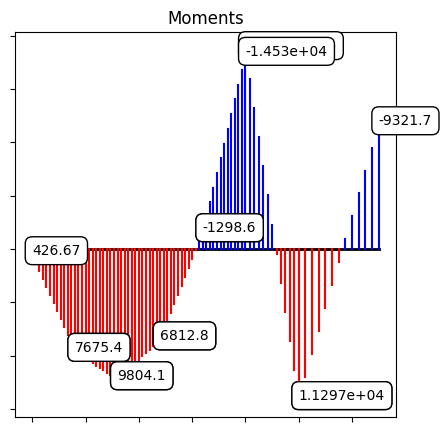

In [53]:
model.number_dofs(m)
model.solve_statics(m)
plots.setup(m)
plots.plot_members(m)
ax = plots.plot_bending_moments(m, scale=0.0005)
ax.set_title("Moments")
plots.show(m)


Clearly, the bending moments are more accurate with the multiple elements per
member. The bending moment at the left hand side is much closer to zero, as it
should be.

Next we again calculate the reactions at the supports.


In [54]:
model.statics_reactions(m)
for j in m["joints"].values():
    if "reactions" in j:
        print(f"{j['jid']}: {j['reactions']}")

a: {1: np.float64(6130.434782608689)}
b: {1: np.float64(22996.52173913041)}
c: {0: np.float64(0.0), 1: np.float64(6873.043478260872), 2: np.float64(-9321.739130434786)}


Finally, we make it possible to employ an arbitrary number of elements within
the left hand side span.


In [55]:

m = model.create(2)
model.add_joint(m, "a", [0.0, 0.0])
model.add_joint(m, "b", [8.0, 0.0])
model.add_joint(m, "d", [10.0, 0.0])
model.add_joint(m, "c", [13.0, 0.0])
model.add_support(m["joints"]["c"], freedoms.ALL_DOFS)
model.add_support(m["joints"]["a"], freedoms.U2)
model.add_support(m["joints"]["b"], freedoms.U2)
model.add_beam_member(m, "rs-1", ["b", "d"], rss)
model.add_beam_member(m, "rs-2", ["d", "c"], rss)
model.add_load(m["joints"]["d"], freedoms.U2, -20e3)

Here we will use 10 elements within the left hand side span.


In [56]:
nsub = 10



We start with the element from the left support to the first intermediate
joint.


In [57]:
model.add_beam_member(m, "ls-1", ["a", 1], lss)


Then we generate the intermediate joins and elements.


In [58]:
for ajid in range(nsub - 2):
    model.add_joint(m, ajid + 1, [(ajid + 1) / (nsub) * 8.0, 0.0])
    model.add_beam_member(m, f"ls-{ajid+2}", [ajid + 1, ajid + 2], lss)


Finally, we add the last element from the last intermediate joint to the right
support.


In [59]:
model.add_joint(m, nsub - 1, [(nsub - 1) / (nsub) * 8.0, 0.0])
model.add_beam_member(m, f"ls-{nsub}", [nsub - 1, "b"], lss)

For each of the elements, equivalent node loads are calculated based on its
length, as before.


In [60]:
for sub in range(1, nsub + 1):
    member = m["beam_members"][f"ls-{sub}"]
    i, j = (
        m["joints"][member["connectivity"][0]],
        m["joints"][member["connectivity"][1]],
    )
    h = geometry.vlen(i["coordinates"], j["coordinates"])
    model.add_load(i, freedoms.U2, -q * h / 2)
    model.add_load(j, freedoms.U2, -q * h / 2)
    model.add_load(i, freedoms.UR3, -q * h**2 / 12)
    model.add_load(j, freedoms.UR3, +q * h**2 / 12)

Solve the problem, report the bending moments.


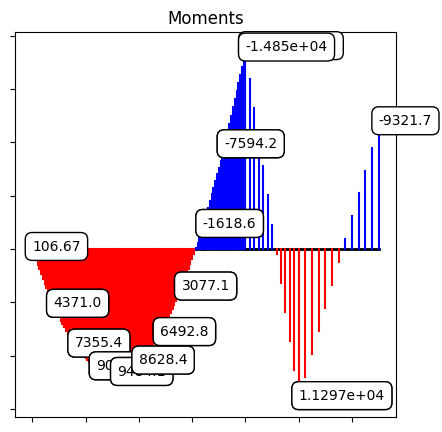

In [61]:
model.number_dofs(m)
model.solve_statics(m)
plots.setup(m)
plots.plot_members(m)
ax = plots.plot_bending_moments(m, scale=0.0005)
ax.set_title("Moments")
plots.show(m)


The bending moment representation can be made arbitrarily accurate by
employing more and more elements on the span with the distributed load.

Next we again calculate the reactions at the supports. Note that the
reactions did not change relative to the other, coarser, models.


In [62]:
model.statics_reactions(m)
for j in m["joints"].values():
    if "reactions" in j:
        print(f"{j['jid']}: {j['reactions']}")

a: {1: np.float64(6130.434782608529)}
b: {1: np.float64(22996.5217391303)}
c: {0: np.float64(0.0), 1: np.float64(6873.043478260923), 2: np.float64(-9321.73913043487)}


## Conclusions

Here we show how to generate multiple elements per member, which in general leads to a better resolution of the problem.